In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

In [2]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.describe

<bound method NDFrame.describe of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                 

In [4]:
df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

## We are going to find the insight on the survival

In [6]:
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


#### survival based on the Passenger Class

In [32]:
survival_count_class = df.loc[df["Survived"] == 1, "Pclass"]

In [33]:
survival_count_class

1      1
2      3
3      1
8      3
9      2
      ..
875    3
879    1
880    2
887    1
889    1
Name: Pclass, Length: 342, dtype: int64

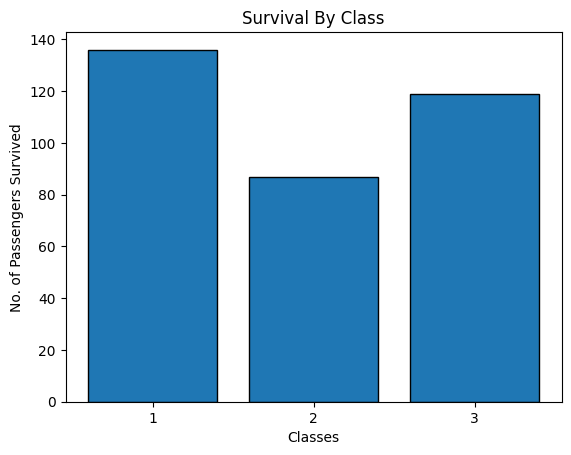

In [57]:
plt.hist(survival_count_class, bins=[0.5, 1.5, 2.5, 3.5], edgecolor = "black", rwidth = 0.8)
plt.xticks([1, 2, 3])
plt.xlabel("Classes")
plt.ylabel("No. of Passengers Survived")
plt.title("Survival By Class")
plt.show()
# Class-1 passengers survived more than any other class

In [79]:
survival_count_class = df.loc[df["Survived"] == 1, "Pclass"].value_counts()

In [80]:
survival_count_class

Pclass
1    136
3    119
2     87
Name: count, dtype: int64

In [86]:
survival_count_class = survival_count_class.sort_index() # we have to sort the data by index as we want classes : 1, 2, 3

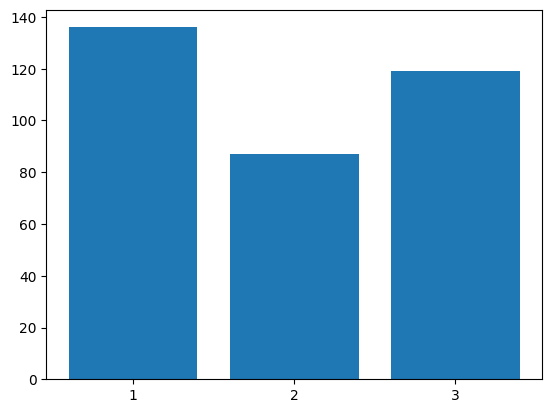

In [85]:
plt.bar(survival_count_class.index, survival_count_class.values)
plt.xticks([1, 2, 3])
plt.show()

In [94]:
rate_survival = np.round(survival_count_class.values / len(df), 2) # total no. of survivors from every class that survived from the total

In [97]:
rate_survival

array([0.15, 0.1 , 0.13])

class 1 -> 136 / 891 = 0.15

class 2 -> 87 / 891  = 0.1

class 3 -> 119 / 891 = 0.13

In [100]:
df.groupby("Pclass")["Survived"].mean().round(2) # Total percentage of survivors from every class

Pclass
1    0.63
2    0.47
3    0.24
Name: Survived, dtype: float64

class 1 -> 136 / 216 = 0.63

class 2 -> 87 / 184  = 0.47

class 3 -> 119 / 491 = 0.24

In [67]:
survival_count_gender = df.loc[df["Survived"] == 1, "Sex"].value_counts()
# value_counts() -> counts the no. of survivers according to the class

In [68]:
survival_count_gender

Sex
female    233
male      109
Name: count, dtype: int64

In [75]:
survival_count_gender.index

Index(['female', 'male'], dtype='object', name='Sex')

In [76]:
survival_count_gender.values

array([233, 109])

        Index	   Value

        female	    233
        male	    109

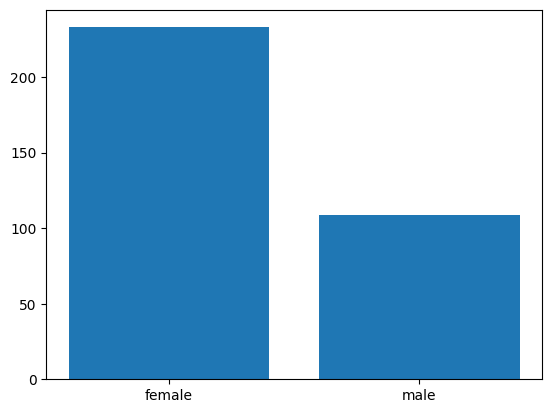

In [78]:
plt.bar(survival_count_gender.index, survival_count_gender.values) # x-axis -> [female, male], y-axis -> [233, 109]
plt.show()